## 1. Project Overview

# Premier League Match Prediction - Exploratory Data Analysis

## Objective

This notebook explores the cleaned Premier League dataset and identifies patterns, relationships, and potential predictive features that may help forecast match outcomes.

The analysis focuses on:

- Dataset structure and quality
- Distribution of match outcomes
- Team performance metrics
- Home-field advantage
- Relationships between match statistics and results
- Potential features for machine learning models

## 2. Data Loading

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/epl_combined_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3800, 25)


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2016_2017,E0,2016-08-13,NaN,Burnley,Swansea,0,1,A,0,...,3,9,10,14,7,4,3,2,0,0
1,2016_2017,E0,2016-08-13,NaN,Crystal Palace,West Brom,0,1,A,0,...,4,3,12,15,3,6,2,2,0,0
2,2016_2017,E0,2016-08-13,NaN,Everton,Tottenham,1,1,D,1,...,6,4,10,14,5,6,0,0,0,0
3,2016_2017,E0,2016-08-13,NaN,Hull,Leicester,2,1,H,1,...,5,5,8,17,5,3,2,2,0,0
4,2016_2017,E0,2016-08-13,NaN,Man City,Sunderland,2,1,H,1,...,4,3,11,14,9,6,1,2,0,0


The dataset contains match-level information across multiple Premier League seasons, including:

- Match metadata (season, date, teams)
- Match outcomes
- Goals scored
- Shots and shots on target
- Fouls
- Corners
- Yellow cards
- Red cards

This dataset will serve as the foundation for exploratory analysis and feature engineering.

## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 25 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Season    3800 non-null   str  
 1   Div       3800 non-null   str  
 2   Date      3800 non-null   str  
 3   Time      2660 non-null   str  
 4   HomeTeam  3800 non-null   str  
 5   AwayTeam  3800 non-null   str  
 6   FTHG      3800 non-null   int64
 7   FTAG      3800 non-null   int64
 8   FTR       3800 non-null   str  
 9   HTHG      3800 non-null   int64
 10  HTAG      3800 non-null   int64
 11  HTR       3800 non-null   str  
 12  Referee   3800 non-null   str  
 13  HS        3800 non-null   int64
 14  AS        3800 non-null   int64
 15  HST       3800 non-null   int64
 16  AST       3800 non-null   int64
 17  HF        3800 non-null   int64
 18  AF        3800 non-null   int64
 19  HC        3800 non-null   int64
 20  AC        3800 non-null   int64
 21  HY        3800 non-null   int64
 22  AY        3

### Observations

- The dataset contains 3,800 matches and 25 variables.
- There are 16 numerical features and 9 categorical features.
- Most columns contain complete data with no missing values.
- The only column with missing values is `Time`, which contains 2,660 non-null values and 1,140 missing values.
- Match dates are currently stored as strings and may need conversion to datetime format for time-based analysis and feature engineering.
- Key predictive variables include shots, shots on target, fouls, corners, yellow cards, and red cards.
- The target variable for match prediction is `FTR` (Full Time Result).

## 4. Data Quality Assessment

In [4]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Time    1140
dtype: int64

### Findings

The dataset is highly complete, with only one column containing missing values.

| Column | Missing Values |
|----------|----------|
| Time | 1,140 |

Key observations:

- Approximately 30% of matches are missing kickoff times.
- All match statistics and outcome variables contain complete data.
- No missing values were found in goals, shots, fouls, corners, cards, teams, or match results.
- Since kickoff time is unlikely to be a primary predictor of match outcomes and contains substantial missingness, it may be excluded from future modeling efforts.

## 5. Target Variable Analysis

The target variable for match prediction is `FTR` (Full Time Result).

Possible values:

- H = Home Win
- D = Draw
- A = Away Win

This section evaluates the distribution of match outcomes and identifies any class imbalance that may affect model training.

In [5]:
df["FTR"].value_counts()

FTR
H    1696
A    1221
D     883
Name: count, dtype: int64

In [6]:
(df["FTR"].value_counts(normalize=True) * 100).round(2)

FTR
H    44.63
A    32.13
D    23.24
Name: proportion, dtype: float64

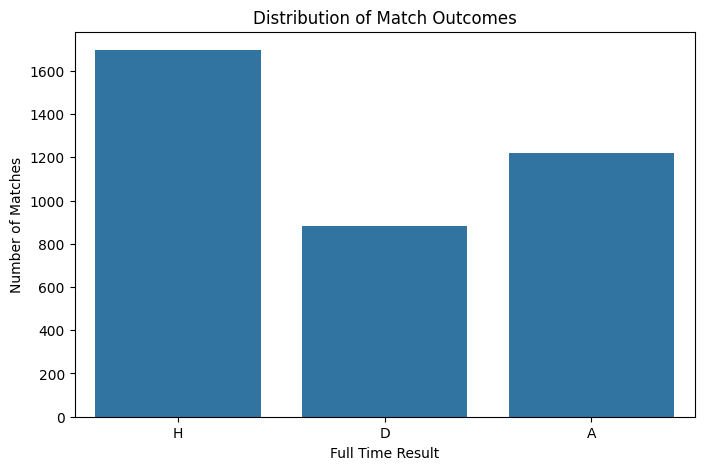

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="FTR",
    data=df,
    order=["H", "D", "A"]
)

plt.title("Distribution of Match Outcomes")
plt.xlabel("Full Time Result")
plt.ylabel("Number of Matches")

plt.show()

### Findings

The target variable (`FTR`) is reasonably balanced across the three possible match outcomes.

| Result | Count | Percentage |
|----------|----------|----------|
| Home Win (H) | 1,696 | 44.63% |
| Away Win (A) | 1,221 | 32.13% |
| Draw (D) | 883 | 23.24% |

Key observations:

- Home wins are the most common outcome, accounting for nearly 45% of all matches.
- Away wins occur in approximately 32% of matches.
- Draws are the least common outcome at approximately 23%.
- The results provide evidence of a home-field advantage in the Premier League.
- Although the classes are not perfectly balanced, the imbalance is not severe enough to immediately require resampling techniques.

In [8]:
majority_class_accuracy = df["FTR"].value_counts(normalize=True).max()

print(f"Majority Class Baseline: {majority_class_accuracy:.2%}")

Majority Class Baseline: 44.63%


## 6. Match Statistics Analysis

In [9]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,1.555263,1.279737,0.697895,0.564211,13.867105,11.480263,4.768158,4.023421,10.598158,10.868158,5.664474,4.687632,1.656579,1.850000,0.053947,0.061053
std,1.313304,1.207771,0.847582,0.780172,5.685582,5.060168,2.618839,2.362564,3.426335,3.562880,3.060554,2.796334,1.271598,1.311911,0.236196,0.244893
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,2.000000,8.000000,8.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,11.000000,4.000000,4.000000,10.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,5.000000,13.000000,13.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,37.000000,37.000000,17.000000,15.000000,24.000000,26.000000,19.000000,19.000000,7.000000,8.000000,2.000000,2.000000


### Findings

#### Goals

- Home teams score an average of 1.56 goals per match.
- Away teams score an average of 1.28 goals per match.
- The higher average goals scored by home teams provides additional evidence of home-field advantage.

#### Shots

- Home teams average 13.87 shots per match.
- Away teams average 11.48 shots per match.
- Home teams generate approximately 2.4 more shots per match than away teams.

#### Shots on Target

- Home teams average 4.77 shots on target.
- Away teams average 4.02 shots on target.
- The difference in shots on target is smaller than total shots, suggesting that shot quality may be important.

#### Fouls

- Both teams commit approximately 10–11 fouls per match.
- Fouls appear relatively balanced between home and away teams.

#### Corners

- Home teams average 5.66 corners per match.
- Away teams average 4.69 corners per match.
- Home teams generate roughly one additional corner per match on average.

#### Discipline

- Away teams receive more yellow cards on average (1.85) than home teams (1.66).
- Red cards are rare, averaging less than 0.1 per team per match.

#### Data Quality

- Maximum values appear realistic and within expected football match ranges.
- No obvious anomalies or impossible values are present in the summary statistics.

## 7. Home Advantage Analysis

In [10]:
home_win_pct = (df["FTR"] == "H").mean() * 100
draw_pct = (df["FTR"] == "D").mean() * 100
away_win_pct = (df["FTR"] == "A").mean() * 100

print(f"Home Win %: {home_win_pct:.2f}")
print(f"Draw %: {draw_pct:.2f}")
print(f"Away Win %: {away_win_pct:.2f}")

Home Win %: 44.63
Draw %: 23.24
Away Win %: 32.13


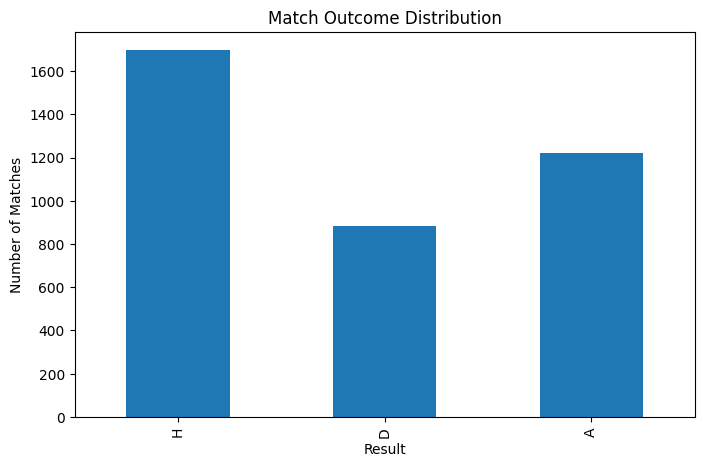

In [11]:
outcomes = df["FTR"].value_counts().reindex(["H", "D", "A"])

plt.figure(figsize=(8,5))
outcomes.plot(kind="bar")

plt.title("Match Outcome Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

### Findings

The results provide strong evidence of a home-field advantage in the Premier League.

| Outcome | Percentage |
|----------|----------|
| Home Win | 44.63% |
| Draw | 23.24% |
| Away Win | 32.13% |

Key observations:

- Home teams win nearly 45% of all matches.
- Away teams win approximately 32% of matches.
- Home teams are roughly 1.4 times more likely to win than away teams.
- Draws account for approximately one-quarter of all matches.
- The distribution of outcomes supports the existence of a measurable home-field advantage.

This finding is consistent with the higher average values observed for home teams in goals scored, shots, shots on target, and corners.

## 8. Pre-Match Predictive Feature Ideas

The goal of this project is to predict match results before kickoff. Because of that, the model should not use statistics from the match being predicted, such as full-time goals, half-time goals, shots, shots on target, corners, fouls, or cards from that same match.

Those match-level statistics are still useful for feature engineering when they are converted into historical pre-match features. For example, a team's shots on target in its previous five matches could be used to predict a future match, but its shots on target in the future match itself would be data leakage.

### Candidate Pre-Match Feature Groups

| Feature Group | Example Features | Why It May Help |
|---|---|---|
| Recent form | Last 5 points, wins, draws, losses, goal difference | Captures current team performance trend |
| Home/away form | Home team's recent home points, away team's recent away points | Accounts for venue-specific strength |
| Attacking strength | Rolling goals scored, shots, shots on target, shot accuracy | Measures chance creation and finishing quality |
| Defensive strength | Rolling goals conceded, shots conceded, shots on target conceded | Measures how difficult a team is to score against |
| Discipline | Rolling yellow cards, red cards, fouls | Captures aggressive or risky playing style |
| Set-piece pressure | Rolling corners won and corners conceded | Proxy for territorial pressure and attacking volume |
| Schedule context | Days since previous match, matches in last 14 days | Captures fatigue and fixture congestion |
| Head-to-head history | Previous meetings, recent head-to-head points, goal difference | Captures matchup-specific patterns |
| Season timing | Month, match week, early/mid/late season | Captures seasonal context and changing incentives |

In [ ]:
pre_match_feature_ideas = pd.DataFrame({
    "feature_group": [
        "Recent form",
        "Home/away form",
        "Attacking strength",
        "Defensive strength",
        "Discipline",
        "Set-piece pressure",
        "Schedule context",
        "Head-to-head history",
        "Season timing",
    ],
    "example_features": [
        "last_5_points, last_5_goal_diff, last_5_win_rate",
        "home_last_5_home_points, away_last_5_away_points",
        "rolling_goals_for, rolling_shots, rolling_shots_on_target, rolling_shot_accuracy",
        "rolling_goals_against, rolling_shots_against, rolling_sot_against",
        "rolling_yellow_cards, rolling_red_cards, rolling_fouls",
        "rolling_corners_for, rolling_corners_against",
        "days_since_last_match, matches_last_14_days",
        "h2h_points_last_5, h2h_goal_diff_last_5",
        "match_month, match_week, season_stage",
    ],
    "priority": [
        "High",
        "High",
        "High",
        "High",
        "Medium",
        "Medium",
        "Medium",
        "Low",
        "Low",
    ]
})

pre_match_feature_ideas

### Recommended Starting Features

The first modeling dataset should focus on features that are available before kickoff and can be computed consistently for both teams.

Recommended first pass:

- Home and away team rolling points over the previous 5 matches.
- Home and away team rolling goal difference over the previous 5 matches.
- Home team recent home form and away team recent away form.
- Rolling goals scored and goals conceded for each team.
- Rolling shots on target for and against each team.
- Rolling shot accuracy for each team.
- Days since each team's previous match.

These features directly connect to the EDA findings: home advantage, goals, shot volume, and shot quality all appear relevant, but they need to be represented using only information from matches that happened before the match being predicted.

## 9. Season-Level Trends

Season-level analysis helps determine whether league-wide patterns are stable over time. This is important for modeling because a model trained on older seasons should still generalize to newer seasons.

In [ ]:
season_summary = df.groupby("Season").agg(
    matches=("FTR", "count"),
    home_win_rate=("FTR", lambda x: (x == "H").mean()),
    draw_rate=("FTR", lambda x: (x == "D").mean()),
    away_win_rate=("FTR", lambda x: (x == "A").mean()),
    avg_home_goals=("FTHG", "mean"),
    avg_away_goals=("FTAG", "mean"),
    avg_total_goals=("FTHG", lambda x: (x + df.loc[x.index, "FTAG"]).mean())
)

rate_columns = ["home_win_rate", "draw_rate", "away_win_rate"]
season_summary[rate_columns] = season_summary[rate_columns] * 100

season_summary.round(2)

In [ ]:
season_summary[["home_win_rate", "draw_rate", "away_win_rate"]].plot(
    marker="o",
    figsize=(10, 5)
)

plt.title("Match Outcome Rates by Season")
plt.xlabel("Season")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.legend(["Home Win", "Draw", "Away Win"])
plt.tight_layout()
plt.show()

### Findings

- Each season contains the expected 380 matches.
- Home win rate varies from 37.89% in 2020_2021 to 49.21% in 2016_2017, so the home-field advantage is present overall but not equally strong every season.
- The 2020_2021 season is the only season in this dataset where away wins, at 40.26%, were more common than home wins, at 37.89%.
- Draw rate ranges from 18.68% in 2018_2019 to 27.37% in 2025_2026.
- Average total goals range from 2.68 per match in 2017_2018 to 3.28 per match in 2023_2024, suggesting that scoring environment changes by season.
- These season-level changes support adding season timing features and using chronological validation so newer matches are predicted from older matches.

## 10. Team-Level Variation

Team-level analysis is important because pre-match prediction depends heavily on team strength. The same match statistics explored earlier can be transformed into historical team features such as recent points, goals scored, goals conceded, and home/away performance.

In [ ]:
home_team_matches = df[["Season", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].copy()
home_team_matches = home_team_matches.rename(columns={
    "HomeTeam": "Team",
    "AwayTeam": "Opponent",
    "FTHG": "Goals_For",
    "FTAG": "Goals_Against"
})
home_team_matches["Venue"] = "Home"
home_team_matches["Result"] = home_team_matches["FTR"].map({"H": "W", "D": "D", "A": "L"})

away_team_matches = df[["Season", "Date", "AwayTeam", "HomeTeam", "FTAG", "FTHG", "FTR"]].copy()
away_team_matches = away_team_matches.rename(columns={
    "AwayTeam": "Team",
    "HomeTeam": "Opponent",
    "FTAG": "Goals_For",
    "FTHG": "Goals_Against"
})
away_team_matches["Venue"] = "Away"
away_team_matches["Result"] = away_team_matches["FTR"].map({"H": "L", "D": "D", "A": "W"})

team_matches = pd.concat([home_team_matches, away_team_matches], ignore_index=True)
team_matches["Points"] = team_matches["Result"].map({"W": 3, "D": 1, "L": 0})
team_matches["Goal_Diff"] = team_matches["Goals_For"] - team_matches["Goals_Against"]

team_matches.head()

In [ ]:
team_summary = team_matches.groupby("Team").agg(
    matches=("Result", "count"),
    points=("Points", "sum"),
    points_per_match=("Points", "mean"),
    win_rate=("Result", lambda x: (x == "W").mean() * 100),
    goals_for_per_match=("Goals_For", "mean"),
    goals_against_per_match=("Goals_Against", "mean"),
    goal_diff_per_match=("Goal_Diff", "mean")
).sort_values("points_per_match", ascending=False)

team_summary.round(2).head(10)

In [ ]:
venue_summary = team_matches.pivot_table(
    index="Team",
    columns="Venue",
    values="Points",
    aggfunc="mean"
).rename(columns={"Home": "home_points_per_match", "Away": "away_points_per_match"})

venue_summary["home_away_ppm_diff"] = (
    venue_summary["home_points_per_match"] - venue_summary["away_points_per_match"]
)

venue_summary.sort_values("home_away_ppm_diff", ascending=False).round(2).head(10)

In [ ]:
top_teams = team_summary.head(10).sort_values("points_per_match")

top_teams["points_per_match"].plot(kind="barh", figsize=(10, 6))

plt.title("Top Teams by Points per Match")
plt.xlabel("Points per Match")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

### Findings

- The long-form team table contains 7,600 team-match rows, which equals two team records for each of the 3,800 matches.
- The team summary includes 34 different clubs across the 10-season dataset.
- Man City have the strongest overall profile with 2.28 points per match, a 70.79% win rate, 2.38 goals scored per match, and a +1.52 goal difference per match.
- Liverpool, Arsenal, Chelsea, Man United, and Tottenham also rank near the top by points per match, which matches expectations for long-term team strength.
- The bottom of the table shows large performance gaps: Norwich average 0.57 points per match and Ipswich average 0.58 points per match in the available seasons.
- Home and away performance differs by team. For example, Arsenal average 2.21 home points per match compared with 1.61 away points per match, while Liverpool average 2.36 at home and 1.86 away.
- These outputs support creating rolling team-strength features, with separate home-form and away-form versions.

## 11. Key Findings

- The cleaned dataset contains 3,800 Premier League matches across 10 seasons, with 380 matches per season.
- The target variable is `FTR`, representing home win, draw, or away win. Across the full dataset, home wins account for 44.63% of matches, away wins account for 32.13%, and draws account for 23.24%.
- The data shows a clear home-field advantage overall: home teams score 1.56 goals per match on average compared with 1.28 for away teams.
- Home teams also produce more attacking volume, averaging 13.87 shots and 4.77 shots on target per match compared with 11.48 shots and 4.02 shots on target for away teams.
- Season-level outputs show that this advantage changes over time. Home win rate ranges from 37.89% to 49.21%, and 2020_2021 is an unusual season where away wins were more common than home wins.
- Scoring environment also changes by season, with average total goals ranging from 2.68 to 3.28 per match.
- Team-level outputs show substantial differences in long-term team strength. Man City lead the dataset with 2.28 points per match, while the lowest teams are below 0.60 points per match.
- Home and away team summaries show that venue-specific form should be modeled separately rather than relying only on overall team strength.
- Match statistics such as goals, shots, shots on target, corners, fouls, and cards are useful for understanding outcomes, but same-match values should not be used directly in a pre-match prediction model.
- The most relevant modeling features should be historical versions of these statistics, calculated before kickoff.

## 12. Next Steps for Feature Engineering

The next step is to create a modeling dataset where every row represents one match and every feature is known before that match starts.

Recommended next steps:

- Convert `Date` to datetime and sort matches chronologically.
- Build rolling 5-match and 10-match features for each team.
- Create separate home-form and away-form features.
- Calculate rolling attacking metrics: goals scored, shots, shots on target, and shot accuracy.
- Calculate rolling defensive metrics: goals conceded, shots conceded, and shots on target conceded.
- Add rest and schedule features such as days since previous match and matches played in the last 14 days.
- Encode the target variable `FTR` for classification modeling.
- Use a chronological train/test split so the model predicts future matches from past matches.
- Start with simple baseline models such as majority class, logistic regression, random forest, or gradient boosting before trying more complex approaches.